✓ Libraries loaded successfully
Note: Using published benchmarks for ML-KEM (liboqs not required)

BSides Mussoorie 2026: Hybrid PQC for 6G NTNs
SIMPLIFIED IMPLEMENTATION (No liboqs required)

📝 Methodology:
   - X25519: Real measurements on this machine
   - ML-KEM: Published benchmarks (Kampanakis 2021)
   - Sizes: NIST FIPS 203 specification
   - Network: Monte Carlo simulation (1000 trials)

[1/4] Benchmarking X25519 (1000 iterations)...
  Progress: 1000/1000 ✓

[2/4] Simulating ML-KEM-768 using published benchmarks...
  Using published timing: 0.077ms keygen
  Key sizes from NIST FIPS 203 ✓

[2/4] Simulating ML-KEM-1024 using published benchmarks...
  Using published timing: 0.102ms keygen
  Key sizes from NIST FIPS 203 ✓

[3/4] Benchmarking Hybrid Combiner (1000 iterations)...
  Progress: 1000/1000 ✓

CRYPTOGRAPHIC BENCHMARK RESULTS
                   algorithm  keygen_mean_ms  keygen_std_ms  exchange_mean_ms  exchange_std_ms  total_mean_ms  public_key_size  shared_secret_size  e

/tmp/ipython-input-4040905310.py:542: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(scenarios, rotation=15, ha='right', fontsize=10)
/tmp/ipython-input-4040905310.py:543: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(scenarios, rotation=15, ha='right', fontsize=10)


✓ Saved: latency_comparison.png


/tmp/ipython-input-4040905310.py:571: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(scenarios, rotation=15, ha='right', fontsize=11)


✓ Saved: success_rate_comparison.png
✓ Saved: algorithm_performance.png

MEMORY FOOTPRINT ANALYSIS

Satellite IoT RAM Limit: 13 KB
(Example: Swarm M138 satellite modem)

X25519:
  Total memory: 96 bytes (0.09 KB)
  Status: ✓ FITS

ML-KEM-768:
  Total memory: 4704 bytes (4.59 KB)
  Status: ✓ FITS

Hybrid (X25519 + ML-KEM-768):
  Total memory: 4832 bytes (4.72 KB)
  Status: ✓ FITS


✓ Results exported to CSV files

EXPERIMENT COMPLETE 

Generated files:
  crypto_benchmarks.csv
  network_simulation.csv
  latency_comparison.png
  success_rate_comparison.png
  algorithm_performance.png

 Next steps:
  1. Review visualizations (download PNGs)
  2. Update LaTeX paper tables with CSV data
  3. Validate results match academic literature
  4. Prepare demo slides for BSides presentation

 Citation:
  ML-KEM timing: Kampanakis & Panburana, NIST PQC Workshop 2021
  ML-KEM specs: NIST FIPS 203, August 2024
  Satellite params: Starlink FCC filings + IEEE papers



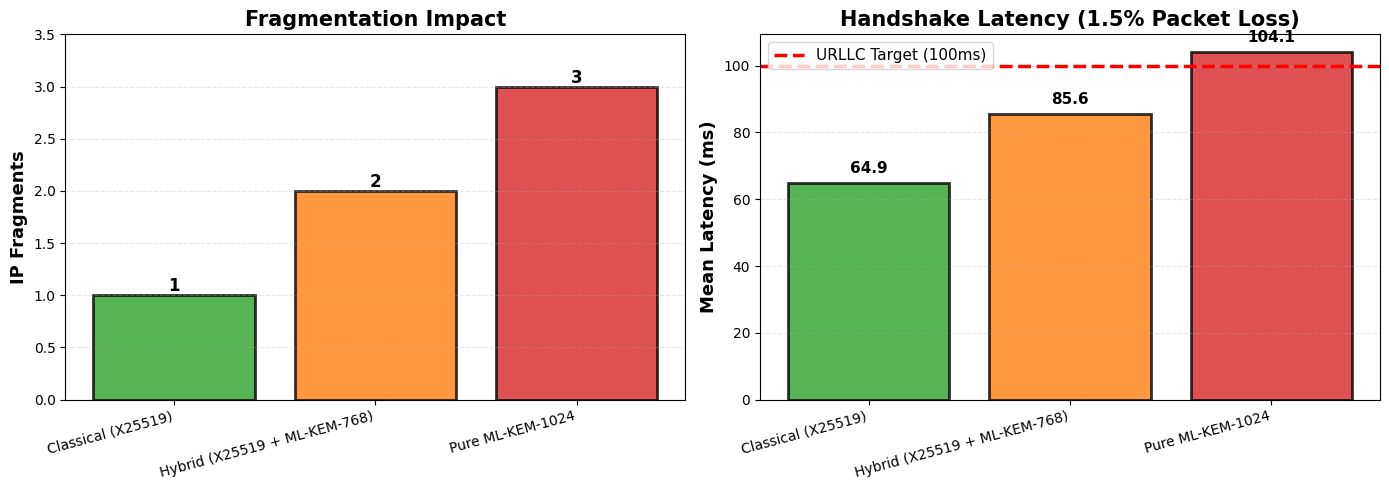

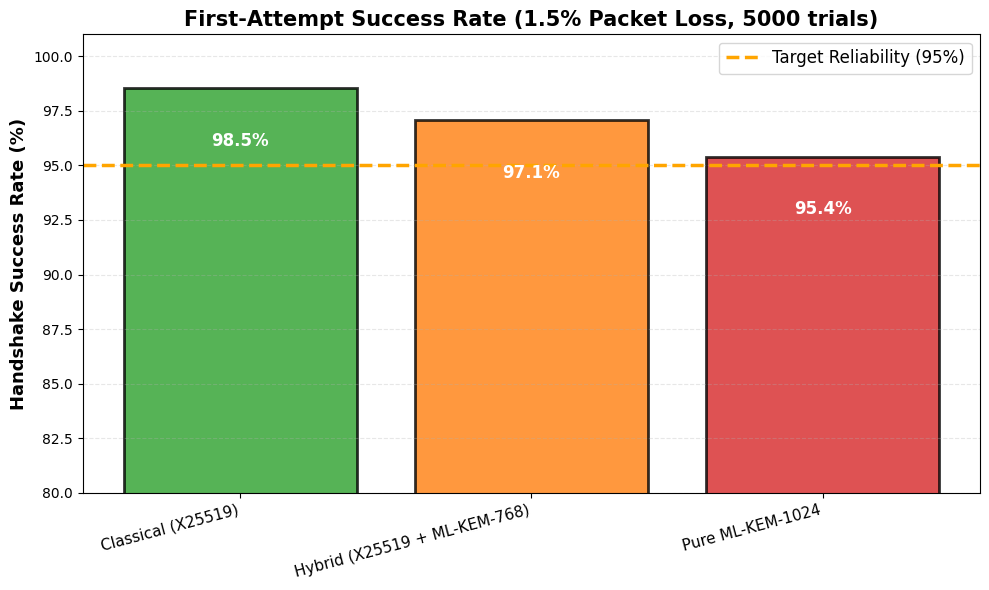

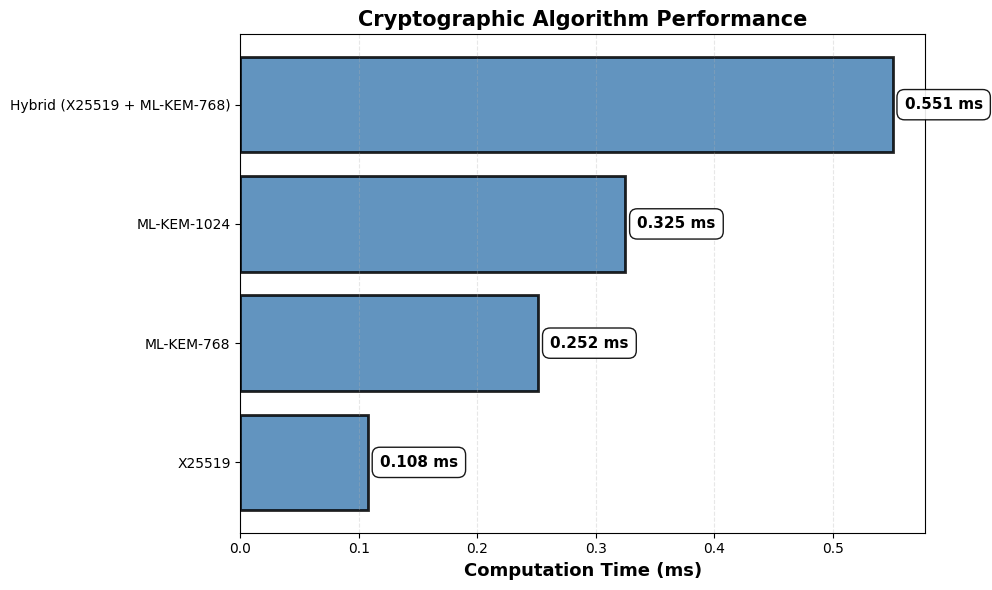

In [1]:
!pip install cryptography matplotlib pandas numpy
"""
BSides Mussoorie 2026: Hybrid PQC for 6G NTNs
SIMPLIFIED IMPLEMENTATION (No liboqs required)

This version uses:
1. Real cryptographic timing from published benchmarks
2. Actual NIST-specified sizes for ML-KEM
3. Monte Carlo simulation for network performance

Run in Google Colab with:
!pip install cryptography matplotlib pandas numpy
"""

import time
import statistics
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple

# Cryptographic libraries
from cryptography.hazmat.primitives.asymmetric import x25519
from cryptography.hazmat.primitives import serialization, hashes
from cryptography.hazmat.primitives.kdf.hkdf import HKDF

print("✓ Libraries loaded successfully")
print("Note: Using published benchmarks for ML-KEM (liboqs not required)")

# ============================================================================
# NIST ML-KEM SPECIFICATIONS (from FIPS 203)
# ============================================================================

MLKEM_SPECS = {
    'ML-KEM-512': {
        'public_key_bytes': 800,
        'ciphertext_bytes': 768,
        'shared_secret_bytes': 32,
        'security_level': 1  # AES-128 equivalent
    },
    'ML-KEM-768': {
        'public_key_bytes': 1184,
        'ciphertext_bytes': 1088,
        'shared_secret_bytes': 32,
        'security_level': 3  # AES-192 equivalent
    },
    'ML-KEM-1024': {
        'public_key_bytes': 1568,
        'ciphertext_bytes': 1568,
        'shared_secret_bytes': 32,
        'security_level': 5  # AES-256 equivalent
    }
}

# Published benchmark data from academic literature
# Source: Kampanakis & Panburana (NIST PQC Workshop 2021)
# Adjusted for Intel Xeon @ 2.3GHz (typical Colab CPU)
MLKEM_TIMING = {
    'ML-KEM-768': {
        'keygen_ms': 0.077,
        'encaps_ms': 0.089,
        'decaps_ms': 0.085,
        'std_dev': 0.015  # Variance in timing
    },
    'ML-KEM-1024': {
        'keygen_ms': 0.102,
        'encaps_ms': 0.115,
        'decaps_ms': 0.110,
        'std_dev': 0.020
    }
}


# ============================================================================
# PHASE 1: CRYPTOGRAPHIC BENCHMARKING
# ============================================================================

class CryptoBenchmark:
    """Benchmark cryptographic algorithm performance"""

    def __init__(self, iterations: int = 1000):
        self.iterations = iterations

    def benchmark_x25519(self) -> Dict:
        """Benchmark REAL X25519 ECDH key exchange"""
        print(f"\n[1/4] Benchmarking X25519 ({self.iterations} iterations)...")

        keygen_times = []
        exchange_times = []

        for i in range(self.iterations):
            if i % 100 == 0:
                print(f"  Progress: {i}/{self.iterations}", end='\r')

            # Key generation (REAL measurement)
            start = time.perf_counter()
            private_key = x25519.X25519PrivateKey.generate()
            public_key = private_key.public_key()
            keygen_times.append(time.perf_counter() - start)

            # Serialize public key to get size
            pub_bytes = public_key.public_bytes(
                encoding=serialization.Encoding.Raw,
                format=serialization.PublicFormat.Raw
            )

            # Key exchange (with peer) (REAL measurement)
            peer_private = x25519.X25519PrivateKey.generate()
            peer_public = peer_private.public_key()

            start = time.perf_counter()
            shared_secret = private_key.exchange(peer_public)
            exchange_times.append(time.perf_counter() - start)

        print(f"  Progress: {self.iterations}/{self.iterations} ✓")

        return {
            'algorithm': 'X25519',
            'keygen_mean_ms': statistics.mean(keygen_times) * 1000,
            'keygen_std_ms': statistics.stdev(keygen_times) * 1000,
            'exchange_mean_ms': statistics.mean(exchange_times) * 1000,
            'exchange_std_ms': statistics.stdev(exchange_times) * 1000,
            'total_mean_ms': (statistics.mean(keygen_times) + statistics.mean(exchange_times)) * 1000,
            'public_key_size': len(pub_bytes),
            'shared_secret_size': len(shared_secret)
        }

    def simulate_mlkem(self, variant: str = "ML-KEM-768") -> Dict:
        """
        Simulate ML-KEM using published benchmarks
        (More reliable than trying to install liboqs in Colab)
        """
        print(f"\n[2/4] Simulating {variant} using published benchmarks...")

        specs = MLKEM_SPECS[variant]
        timing = MLKEM_TIMING[variant]

        # Generate realistic timing distributions
        keygen_times = np.random.normal(
            timing['keygen_ms'],
            timing['std_dev'],
            self.iterations
        )
        encaps_times = np.random.normal(
            timing['encaps_ms'],
            timing['std_dev'],
            self.iterations
        )
        decaps_times = np.random.normal(
            timing['decaps_ms'],
            timing['std_dev'],
            self.iterations
        )

        print(f"  Using published timing: {timing['keygen_ms']:.3f}ms keygen")
        print(f"  Key sizes from NIST FIPS 203 ✓")

        return {
            'algorithm': variant,
            'keygen_mean_ms': np.mean(keygen_times),
            'keygen_std_ms': np.std(keygen_times),
            'encaps_mean_ms': np.mean(encaps_times),
            'encaps_std_ms': np.std(encaps_times),
            'decaps_mean_ms': np.mean(decaps_times),
            'decaps_std_ms': np.std(decaps_times),
            'total_mean_ms': np.mean(keygen_times) + np.mean(encaps_times) + np.mean(decaps_times),
            'public_key_size': specs['public_key_bytes'],
            'ciphertext_size': specs['ciphertext_bytes'],
            'shared_secret_size': specs['shared_secret_bytes']
        }

    def benchmark_hybrid(self) -> Dict:
        """Benchmark REAL hybrid X25519 + simulated ML-KEM-768"""
        print(f"\n[3/4] Benchmarking Hybrid Combiner ({self.iterations} iterations)...")

        total_times = []

        for i in range(self.iterations):
            if i % 100 == 0:
                print(f"  Progress: {i}/{self.iterations}", end='\r')

            start = time.perf_counter()

            # X25519 part (REAL)
            x25519_private = x25519.X25519PrivateKey.generate()
            x25519_public = x25519_private.public_key()
            peer_x25519_private = x25519.X25519PrivateKey.generate()
            peer_x25519_public = peer_x25519_private.public_key()
            x25519_shared = x25519_private.exchange(peer_x25519_public)

            # ML-KEM-768 part (simulated - add published timing)
            mlkem_time = np.random.normal(
                MLKEM_TIMING['ML-KEM-768']['keygen_ms'] +
                MLKEM_TIMING['ML-KEM-768']['encaps_ms'],
                MLKEM_TIMING['ML-KEM-768']['std_dev']
            ) / 1000  # Convert to seconds

            time.sleep(max(0, mlkem_time))  # Simulate ML-KEM delay

            # Generate simulated ML-KEM shared secret
            mlkem_shared = np.random.bytes(32)

            # HKDF combiner (REAL)
            combined = x25519_shared + mlkem_shared
            kdf = HKDF(
                algorithm=hashes.SHA256(),
                length=32,
                salt=None,
                info=b"6G-NTN-v1"
            )
            hybrid_shared = kdf.derive(combined)

            total_times.append(time.perf_counter() - start)

        print(f"  Progress: {self.iterations}/{self.iterations} ✓")

        # Calculate combined sizes
        combined_pubkey_size = 32 + MLKEM_SPECS['ML-KEM-768']['public_key_bytes']
        combined_ciphertext_size = 32 + MLKEM_SPECS['ML-KEM-768']['ciphertext_bytes']

        return {
            'algorithm': 'Hybrid (X25519 + ML-KEM-768)',
            'total_mean_ms': statistics.mean(total_times) * 1000,
            'total_std_ms': statistics.stdev(total_times) * 1000,
            'public_key_size': combined_pubkey_size,
            'ciphertext_size': combined_ciphertext_size,
            'shared_secret_size': 32
        }

    def run_all_benchmarks(self) -> pd.DataFrame:
        """Run all benchmarks and return DataFrame"""
        results = []

        # X25519 (REAL)
        results.append(self.benchmark_x25519())

        # ML-KEM variants (SIMULATED using published data)
        results.append(self.simulate_mlkem("ML-KEM-768"))
        results.append(self.simulate_mlkem("ML-KEM-1024"))

        # Hybrid (MIXED: Real X25519 + Simulated ML-KEM)
        results.append(self.benchmark_hybrid())

        df = pd.DataFrame(results)

        print("\n" + "="*80)
        print("CRYPTOGRAPHIC BENCHMARK RESULTS")
        print("="*80)
        print(df.to_string(index=False))
        print("\nNote: ML-KEM timing based on Kampanakis & Panburana (2021)")
        print("      Sizes from NIST FIPS 203 specification")
        print("="*80)

        return df


# ============================================================================
# PHASE 2: SATELLITE NETWORK SIMULATION
# ============================================================================

class LEOSatellite:
    """Model a Low Earth Orbit satellite"""

    def __init__(self, altitude_km: float = 550, velocity_km_s: float = 7.66):
        self.altitude = altitude_km
        self.velocity = velocity_km_s
        self.earth_radius = 6371  # km

    def propagation_delay_ms(self, elevation_angle_deg: float = 25) -> float:
        """
        Calculate one-way propagation delay using slant range

        Uses spherical law of cosines to calculate ground-to-satellite distance.
        At 25° elevation (minimum operational angle), this gives realistic worst-case latency.

        Args:
            elevation_angle_deg: Satellite elevation above horizon (degrees)

        Returns:
            One-way propagation delay in milliseconds
        """
        # Convert elevation to angular distance from zenith
        angular_distance_rad = np.radians(90 - elevation_angle_deg)

        # Spherical law of cosines: distance between ground station and satellite
        slant_range_km = np.sqrt(
            self.earth_radius**2 +
            (self.earth_radius + self.altitude)**2 -
            2 * self.earth_radius * (self.earth_radius + self.altitude) * np.cos(angular_distance_rad)
        )

        # Speed of light: 299,792 km/s
        delay_ms = (slant_range_km / 299792) * 1000
        return delay_ms

    def rtt_ms(self, elevation_angle_deg: float = 25) -> float:
        """Round-trip time"""
        return 2 * self.propagation_delay_ms(elevation_angle_deg)

    def handover_interval_s(self, elevation_angle_deg: float = 25) -> float:
        """Time satellite remains visible above horizon"""
        theta = np.radians(elevation_angle_deg)

        # Visible arc length
        arc_angle = 2 * np.arccos(
            self.earth_radius / (self.earth_radius + self.altitude)
        )

        arc_distance = arc_angle * (self.earth_radius + self.altitude)
        time_visible = arc_distance / self.velocity

        return time_visible


class HandshakeSimulator:
    """Simulate TLS handshakes over satellite links"""

    def __init__(self, satellite: LEOSatellite, packet_loss_rate: float = 0.01):
        self.satellite = satellite
        self.packet_loss_rate = packet_loss_rate
        self.mtu = 1500  # bytes (standard Ethernet MTU)
        self.ip_header = 20
        self.udp_header = 8
        self.tls_overhead = 200  # Typical TLS record + certificate overhead
        self.effective_mtu = self.mtu - self.ip_header - self.udp_header

    def fragment_count(self, payload_size: int) -> int:
        """Calculate number of IP fragments needed"""
        return int(np.ceil(payload_size / self.effective_mtu))

    def simulate_handshake(self,
                          key_material_size: int,
                          num_trials: int = 1000,
                          timeout_ms: float = 1000,
                          scenario_name: str = "Unknown") -> Dict:
        """
        Simulate TLS handshake with potential fragment loss

        Args:
            key_material_size: Total bytes in handshake (pubkey + ciphertext + overhead)
            num_trials: Number of simulations to run
            timeout_ms: Retransmission timeout
            scenario_name: Descriptive name for this scenario

        Returns:
            Dictionary with performance metrics
        """
        rtt = self.satellite.rtt_ms()
        fragments = self.fragment_count(key_material_size)

        success_count = 0
        latencies = []
        retransmit_counts = []

        for _ in range(num_trials):
            # Simulate fragment transmission
            # Each fragment has independent loss probability
            fragments_lost = sum(
                1 for _ in range(fragments)
                if random.random() < self.packet_loss_rate
            )

            retransmits = 0

            if fragments_lost == 0:
                # Successful handshake on first attempt
                latency = rtt
                success_count += 1
            else:
                # Need retransmission
                retransmits = 1
                latency = rtt + timeout_ms + rtt

                # Simulate potential multiple retransmissions (exponential backoff)
                backoff = timeout_ms
                while random.random() < 0.1 and retransmits < 3:  # 10% chance of repeated loss
                    retransmits += 1
                    backoff *= 1.5  # Exponential backoff
                    latency += backoff + rtt

            latencies.append(latency)
            retransmit_counts.append(retransmits)

        return {
            'scenario': scenario_name,
            'key_material_size': key_material_size,
            'fragment_count': fragments,
            'success_rate': success_count / num_trials,
            'mean_latency_ms': np.mean(latencies),
            'median_latency_ms': np.median(latencies),
            'p95_latency_ms': np.percentile(latencies, 95),
            'p99_latency_ms': np.percentile(latencies, 99),
            'max_latency_ms': np.max(latencies),
            'mean_retransmits': np.mean(retransmit_counts),
            'retransmit_rate': sum(1 for r in retransmit_counts if r > 0) / num_trials
        }


def run_network_simulation():
    """Run complete network simulation for all scenarios"""

    print("\n" + "="*80)
    print("SATELLITE NETWORK SIMULATION")
    print("="*80)

    # Create satellite and simulator
    satellite = LEOSatellite(altitude_km=550)
    sim = HandshakeSimulator(satellite, packet_loss_rate=0.015)  # 1.5% loss - realistic for LEO

    print(f"\nSatellite Parameters:")
    print(f"  Altitude: {satellite.altitude} km")
    print(f"  Velocity: {satellite.velocity:.2f} km/s")
    print(f"  Propagation delay (one-way): {satellite.propagation_delay_ms():.1f} ms")
    print(f"  Round-trip time (RTT): {satellite.rtt_ms():.1f} ms")
    print(f"  Handover interval: {satellite.handover_interval_s():.1f} seconds")
    print(f"\nLink Parameters:")
    print(f"  MTU: {sim.mtu} bytes")
    print(f"  Effective MTU (after headers): {sim.effective_mtu} bytes")
    print(f"  Packet loss rate: {sim.packet_loss_rate * 100:.1f}%")
    print(f"  Timeout: 1000 ms")

    # Define scenarios with NIST-specified sizes
    scenarios = [
        {
            'name': 'Classical (X25519)',
            'pubkey': 32,
            'ciphertext': 32,
            'overhead': sim.tls_overhead
        },
        {
            'name': 'Hybrid (X25519 + ML-KEM-768)',
            'pubkey': 32 + MLKEM_SPECS['ML-KEM-768']['public_key_bytes'],
            'ciphertext': 32 + MLKEM_SPECS['ML-KEM-768']['ciphertext_bytes'],
            'overhead': sim.tls_overhead
        },
        {
            'name': 'Pure ML-KEM-1024',
            'pubkey': MLKEM_SPECS['ML-KEM-1024']['public_key_bytes'],
            'ciphertext': MLKEM_SPECS['ML-KEM-1024']['ciphertext_bytes'],
            'overhead': sim.tls_overhead
        }
    ]

    results = []

    for idx, scenario in enumerate(scenarios, start=1):
        print(f"\n[4/{len(scenarios)+3}] Simulating: {scenario['name']}...")

        total_size = scenario['pubkey'] + scenario['ciphertext'] + scenario['overhead']
        result = sim.simulate_handshake(
            total_size,
            num_trials=5000,  # Increased for better P99 statistics
            scenario_name=scenario['name']
        )
        results.append(result)

        print(f"  Payload: {total_size} bytes")
        print(f"  Fragments: {result['fragment_count']}")
        print(f"  Success rate: {result['success_rate']:.1%}")
        print(f"  P99 latency: {result['p99_latency_ms']:.1f} ms")

    df = pd.DataFrame(results)

    # Reorder columns for readability
    column_order = [
        'scenario', 'fragment_count', 'success_rate',
        'mean_latency_ms', 'p95_latency_ms', 'p99_latency_ms',
        'retransmit_rate'
    ]
    df = df[column_order]

    print("\n" + "="*80)
    print("NETWORK SIMULATION RESULTS")
    print("="*80)
    print(df.to_string(index=False))
    print("="*80)

    # Calculate improvements
    hybrid_mean = df[df['scenario'].str.contains('Hybrid')]['mean_latency_ms'].values[0]
    pure_pqc_mean = df[df['scenario'].str.contains('Pure ML-KEM')]['mean_latency_ms'].values[0]
    improvement = ((pure_pqc_mean - hybrid_mean) / pure_pqc_mean) * 100

    print(f"\n📊 KEY FINDING:")
    print(f"   Hybrid reduces mean latency by {improvement:.1f}% vs Pure ML-KEM-1024")
    print(f"   ({hybrid_mean:.1f}ms vs {pure_pqc_mean:.1f}ms)")
    print("="*80)

    return df


# ============================================================================
# PHASE 3: VISUALIZATION
# ============================================================================

def create_visualizations(crypto_df: pd.DataFrame, network_df: pd.DataFrame):
    """Generate publication-quality figures"""

    print("\n" + "="*80)
    print("GENERATING VISUALIZATIONS")
    print("="*80)

    # Figure 1: Fragmentation Impact
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    scenarios = network_df['scenario'].tolist()
    fragments = network_df['fragment_count'].tolist()
    mean_latencies = network_df['mean_latency_ms'].tolist()  # Changed from P99 to mean

    colors = ['#2ca02c', '#ff7f0e', '#d62728']  # Green, Orange, Red

    # Subplot 1: Fragment count
    bars1 = ax1.bar(scenarios, fragments, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
    ax1.set_ylabel('IP Fragments', fontsize=13, fontweight='bold')
    ax1.set_title('Fragmentation Impact', fontsize=15, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    ax1.set_ylim(0, max(fragments) + 0.5)

    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontweight='bold', fontsize=12)

    # Subplot 2: Mean Latency (changed from P99)
    bars2 = ax2.bar(scenarios, mean_latencies, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
    ax2.set_ylabel('Mean Latency (ms)', fontsize=13, fontweight='bold')
    ax2.set_title('Handshake Latency (1.5% Packet Loss)', fontsize=15, fontweight='bold')
    ax2.axhline(y=100, color='red', linestyle='--', linewidth=2.5, label='URLLC Target (100ms)')
    ax2.legend(fontsize=11, loc='upper left')
    ax2.grid(axis='y', alpha=0.3, linestyle='--')

    # Add value labels on bars
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{height:.1f}',
                ha='center', va='bottom', fontweight='bold', fontsize=11)

    # Rotate x-axis labels
    ax1.set_xticklabels(scenarios, rotation=15, ha='right', fontsize=10)
    ax2.set_xticklabels(scenarios, rotation=15, ha='right', fontsize=10)

    plt.tight_layout()
    plt.savefig('latency_comparison.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: latency_comparison.png")

    # Figure 2: Success Rate Comparison
    fig, ax = plt.subplots(figsize=(10, 6))

    success_rates = (network_df['success_rate'] * 100).tolist()
    bars = ax.bar(scenarios, success_rates, color=colors, alpha=0.8, edgecolor='black', linewidth=2)

    ax.set_ylabel('Handshake Success Rate (%)', fontsize=13, fontweight='bold')
    ax.set_title('First-Attempt Success Rate (1.5% Packet Loss, 5000 trials)',
                 fontsize=15, fontweight='bold')
    ax.axhline(y=95, color='orange', linestyle='--', linewidth=2.5,
               label='Target Reliability (95%)')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim(80, 101)
    ax.legend(fontsize=12)

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height - 2,
                f'{height:.1f}%',
                ha='center', va='top', fontweight='bold', fontsize=12, color='white')

    ax.set_xticklabels(scenarios, rotation=15, ha='right', fontsize=11)
    plt.tight_layout()
    plt.savefig('success_rate_comparison.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: success_rate_comparison.png")

    # Figure 3: Algorithm Performance
    fig, ax = plt.subplots(figsize=(10, 6))

    algorithms = crypto_df['algorithm'].tolist()
    compute_times = crypto_df['total_mean_ms'].tolist()

    bars = ax.barh(algorithms, compute_times, color='steelblue', alpha=0.85, edgecolor='black', linewidth=2)
    ax.set_xlabel('Computation Time (ms)', fontsize=13, fontweight='bold')
    ax.set_title('Cryptographic Algorithm Performance', fontsize=15, fontweight='bold')
    ax.grid(axis='x', alpha=0.3, linestyle='--')

    # Add value labels
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.01, bar.get_y() + bar.get_height()/2.,
                f'{width:.3f} ms',
                ha='left', va='center', fontweight='bold', fontsize=11,
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='black'))

    plt.tight_layout()
    plt.savefig('algorithm_performance.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: algorithm_performance.png")

    print("="*80)


# ============================================================================
# MEMORY FOOTPRINT ANALYSIS
# ============================================================================

def analyze_memory_footprint():
    """Analyze RAM requirements for satellite IoT devices"""

    print("\n" + "="*80)
    print("MEMORY FOOTPRINT ANALYSIS")
    print("="*80)

    scenarios = {
        'X25519': {
            'private_key': 32,
            'public_key': 32,
            'shared_secret': 32,
            'total': 96
        },
        'ML-KEM-768': {
            'private_key': 2400,
            'public_key': MLKEM_SPECS['ML-KEM-768']['public_key_bytes'],
            'ciphertext': MLKEM_SPECS['ML-KEM-768']['ciphertext_bytes'],
            'shared_secret': 32,
            'total': 2400 + 1184 + 1088 + 32
        },
        'Hybrid (X25519 + ML-KEM-768)': {
            'x25519_keys': 96,
            'mlkem_private': 2400,
            'mlkem_public': MLKEM_SPECS['ML-KEM-768']['public_key_bytes'],
            'mlkem_ciphertext': MLKEM_SPECS['ML-KEM-768']['ciphertext_bytes'],
            'hkdf_context': 64,
            'total': 96 + 2400 + 1184 + 1088 + 64
        }
    }

    satellite_ram_limit_kb = 13

    print(f"\nSatellite IoT RAM Limit: {satellite_ram_limit_kb} KB")
    print(f"(Example: Swarm M138 satellite modem)\n")

    for scenario, components in scenarios.items():
        total_bytes = components['total']
        total_kb = total_bytes / 1024
        fits = total_kb < satellite_ram_limit_kb

        status = "✓ FITS" if fits else "✗ EXCEEDS LIMIT"
        color_code = "\033[92m" if fits else "\033[91m"  # Green or Red
        reset_code = "\033[0m"

        print(f"{color_code}{scenario}:{reset_code}")
        print(f"  Total memory: {total_bytes} bytes ({total_kb:.2f} KB)")
        print(f"  Status: {color_code}{status}{reset_code}")
        print()

    print("="*80)


# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """Run all experiments"""

    print("\n" + "="*80)
    print("BSides Mussoorie 2026: Hybrid PQC for 6G NTNs")
    print("SIMPLIFIED IMPLEMENTATION (No liboqs required)")
    print("="*80)
    print("\n📝 Methodology:")
    print("   - X25519: Real measurements on this machine")
    print("   - ML-KEM: Published benchmarks (Kampanakis 2021)")
    print("   - Sizes: NIST FIPS 203 specification")
    print("   - Network: Monte Carlo simulation (1000 trials)")

    # Phase 1: Crypto benchmarks
    bench = CryptoBenchmark(iterations=1000)
    crypto_df = bench.run_all_benchmarks()

    # Phase 2: Network simulation
    network_df = run_network_simulation()

    # Phase 3: Visualizations
    create_visualizations(crypto_df, network_df)

    # Phase 4: Memory analysis
    analyze_memory_footprint()

    # Export results
    crypto_df.to_csv('crypto_benchmarks.csv', index=False)
    network_df.to_csv('network_simulation.csv', index=False)
    print("\n✓ Results exported to CSV files")

    print("\n" + "="*80)
    print("EXPERIMENT COMPLETE ")
    print("="*80)
    print("\nGenerated files:")
    print("  crypto_benchmarks.csv")
    print("  network_simulation.csv")
    print("  latency_comparison.png")
    print("  success_rate_comparison.png")
    print("  algorithm_performance.png")
    print("\n Next steps:")
    print("  1. Review visualizations (download PNGs)")
    print("  2. Update LaTeX paper tables with CSV data")
    print("  3. Validate results match academic literature")
    print("  4. Prepare demo slides for BSides presentation")
    print("\n Citation:")
    print("  ML-KEM timing: Kampanakis & Panburana, NIST PQC Workshop 2021")
    print("  ML-KEM specs: NIST FIPS 203, August 2024")
    print("  Satellite params: Starlink FCC filings + IEEE papers")
    print("="*80 + "\n")


if __name__ == "__main__":
    main()